In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    SGDRegressor,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
df = pd.read_csv("yield_df.csv")

In [4]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [5]:
df.shape

(28242, 8)

In [6]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [8]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [9]:
df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Remove the unnecessary index column:

In [10]:
df = df.drop(columns=["Unnamed: 0"])

Verify:

In [11]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


Histogram of Yield

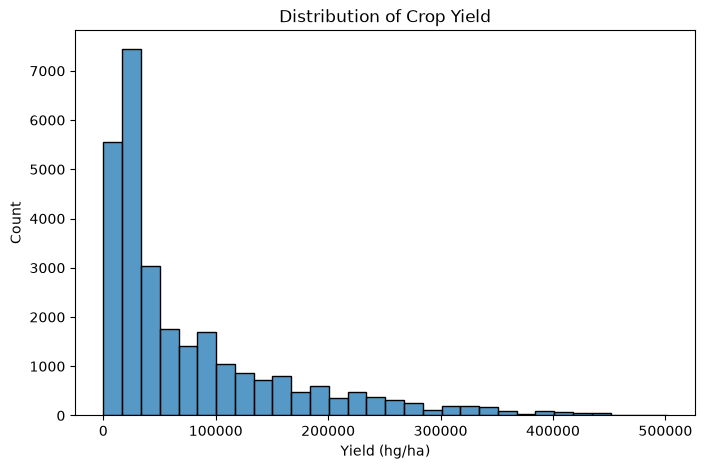

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["hg/ha_yield"], bins=30)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (hg/ha)")
plt.show()

Histogram of Rainfall

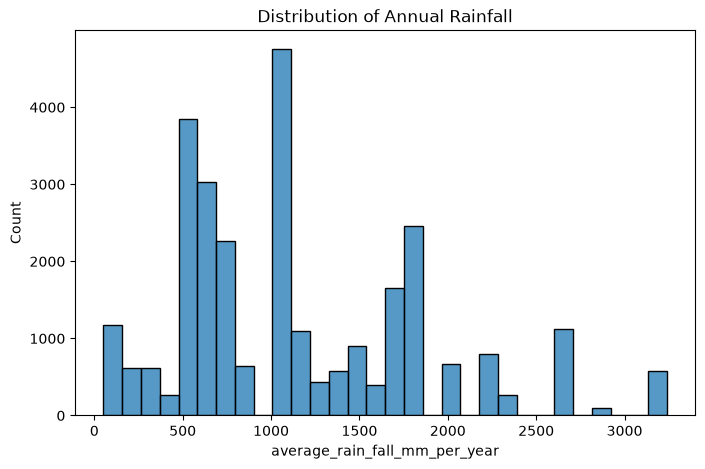

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["average_rain_fall_mm_per_year"], bins=30)
plt.title("Distribution of Annual Rainfall")
plt.show()

Histogram of Temperature

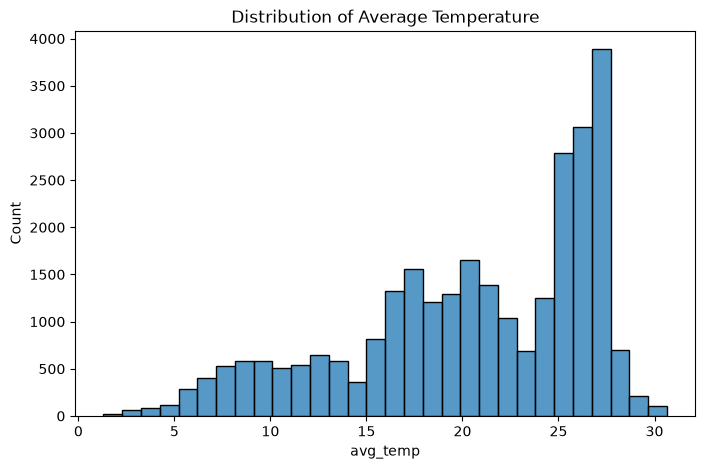

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["avg_temp"], bins=30)
plt.title("Distribution of Average Temperature")
plt.show()

Scatter Plot

Scatter Plot

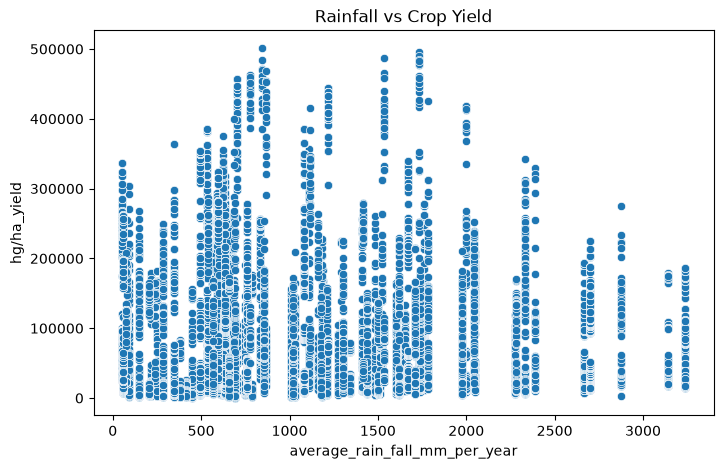

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["average_rain_fall_mm_per_year"],
    y=df["hg/ha_yield"]
)
plt.title("Rainfall vs Crop Yield")
plt.show()

Scatter Plot

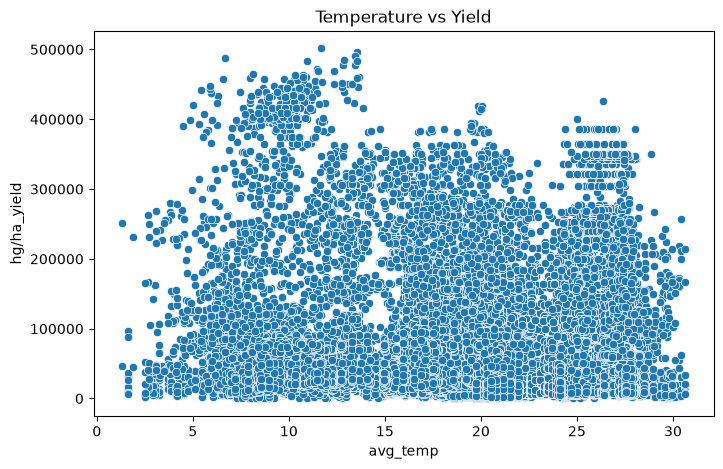

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["avg_temp"],
    y=df["hg/ha_yield"]
)
plt.title("Temperature vs Yield")
plt.show()

Scatter Plot

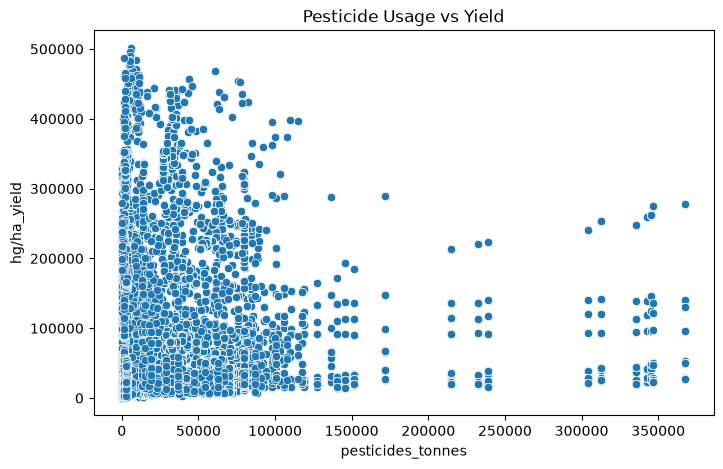

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["pesticides_tonnes"],
    y=df["hg/ha_yield"]
)
plt.title("Pesticide Usage vs Yield")
plt.show()

Correlation Heatmap

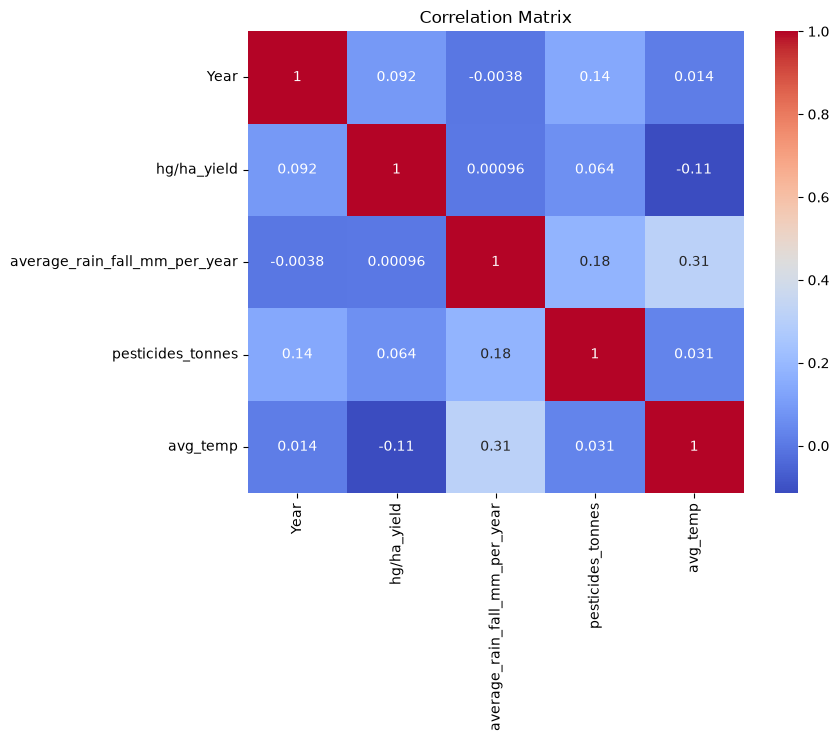

In [18]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Separate features and target

In [19]:
X = df.drop(columns=["hg/ha_yield"])
y = df["hg/ha_yield"]

Identify categorical and numerical columns

In [20]:
categorical_features = ["Area", "Item"]

numerical_features = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

Create the preprocessing pipeline

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Split the Dataset

In [22]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (22593, 6)
Testing samples: (5649, 6)


Build the Models

In [23]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

sgd_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        max_iter=5000,
        learning_rate="adaptive",
        eta0=0.01,
        random_state=42
    ))
])

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01))
])

Train the Models

In [24]:
linear_pipeline.fit(X_train, y_train)

sgd_pipeline.fit(X_train, y_train)

ridge_pipeline.fit(X_train, y_train)

lasso_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Area','Item','Year','average_rain_fall_mm_per_year','pesticides_tonnes', 'avg_temp']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

Create an Evaluation Function

In [25]:
def evaluate_model(model, model_name):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    }

Compare the Models

In [26]:
results = []

results.append(
    evaluate_model(linear_pipeline, "Linear Regression")
)

results.append(
    evaluate_model(sgd_pipeline, "SGD Regressor")
)

results.append(
    evaluate_model(ridge_pipeline, "Ridge Regression")
)

results.append(
    evaluate_model(lasso_pipeline, "Lasso Regression")
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,29582.514374,1.776121e+09,42144.046086,0.755142
1,SGD Regressor,29519.169442,1.777828e+09,42164.300725,0.754906
2,Ridge Regression,29542.187893,1.776007e+09,42142.698435,0.755158
3,Lasso Regression,29582.281322,1.776118e+09,42144.016457,0.755142


Highlight the Best Model

In [27]:
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R² Score
2,Ridge Regression,29542.187893,1.776007e+09,42142.698435,0.755158
3,Lasso Regression,29582.281322,1.776118e+09,42144.016457,0.755142
0,Linear Regression,29582.514374,1.776121e+09,42144.046086,0.755142
1,SGD Regressor,29519.169442,1.777828e+09,42164.300725,0.754906


Save the Best Model Automatically

In [28]:
models = {
    "Linear Regression": linear_pipeline,
    "SGD Regressor": sgd_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline
}

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")

print("Selected model:", best_model_name)

Best model saved successfully!
Selected model: Ridge Regression


Test the Saved Model

In [29]:
loaded_model = joblib.load("best_model.pkl")

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Yield:", prediction[0])

print("Actual Yield:", y_test.iloc[0])

Predicted Yield: 83697.56901452188
Actual Yield: 69220


Train for Multiple Epochs

In [30]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

# Load the dataset (duplicated for cell independence)
df = pd.read_csv("yield_df.csv")

# Define features (duplicated for cell independence)
categorical_features = ["Area", "Item"]

numerical_features = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

# Define preprocessor (duplicated for cell independence)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Define X and y (duplicated for cell independence)
X = df.drop(columns=["hg/ha_yield"])
y = df["hg/ha_yield"]

# Split the dataset into training and testing sets (duplicated for cell independence)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create a fresh SGD model
sgd_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        random_state=42,
        learning_rate="adaptive",
        eta0=0.01,
        warm_start=True # Removed max_iter=1 to allow more iterations per fit
    ))
])

epochs = 100

train_loss = []
test_loss = []

for epoch in range(epochs):

    sgd_model.fit(X_train, y_train)

    train_predictions = sgd_model.predict(X_train)

    test_predictions = sgd_model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_predictions)

    test_mse = mean_squared_error(y_test, test_predictions)

    train_loss.append(train_mse)

    test_loss.append(test_mse)

Plot Training Loss

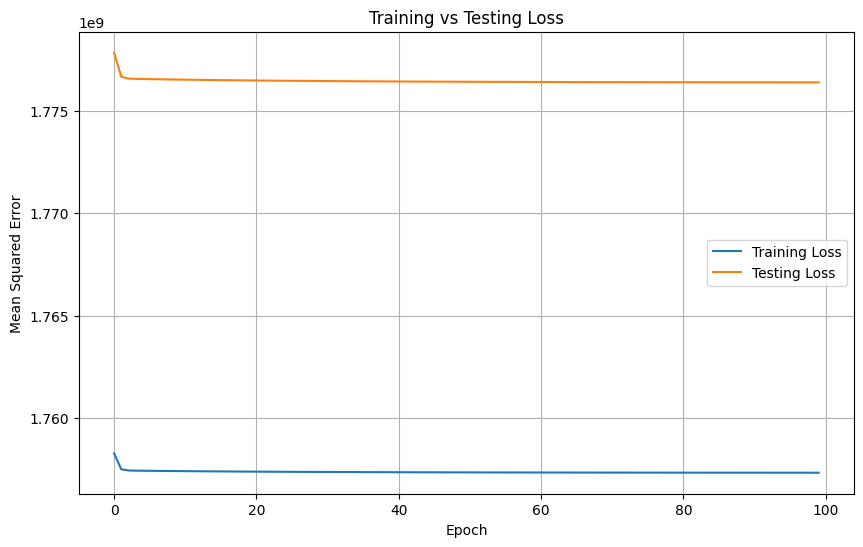

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(train_loss,label="Training Loss")

plt.plot(test_loss,label="Testing Loss")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.title("Training vs Testing Loss")

plt.legend()

plt.grid(True)

plt.show()

Actual vs Predicted

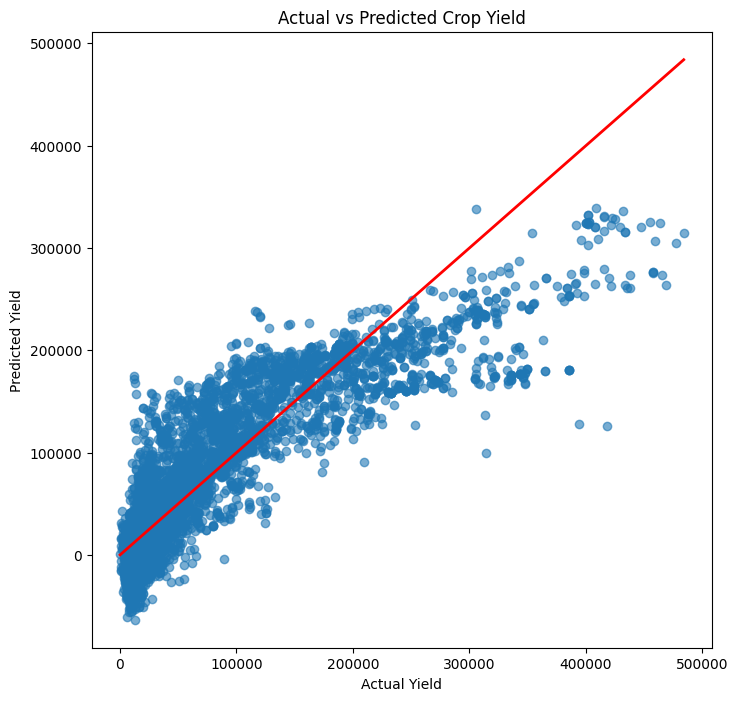

In [ ]:
import joblib
import matplotlib.pyplot as plt

# Load the best model
best_model = joblib.load("best_model.pkl")

best_predictions = best_model.predict(X_test)

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Crop Yield")

plt.show()

Before and After Regression

Before

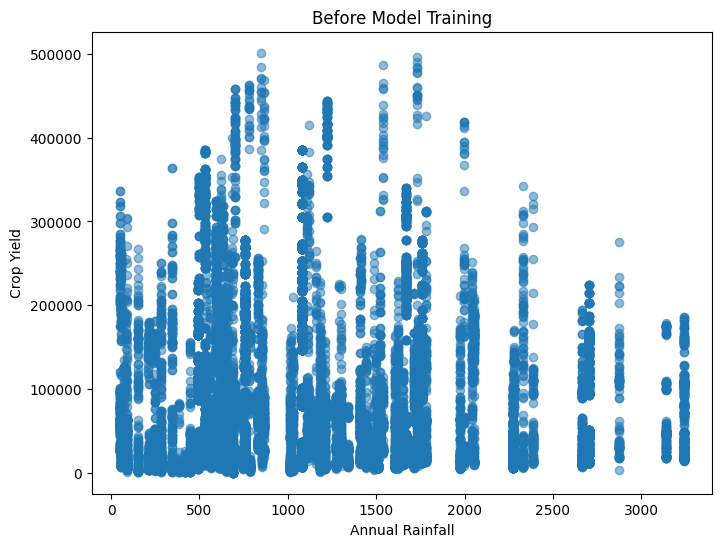

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["average_rain_fall_mm_per_year"],
    df["hg/ha_yield"],
    alpha=0.5
)

plt.xlabel("Annual Rainfall")

plt.ylabel("Crop Yield")

plt.title("Before Model Training")

plt.show()

After

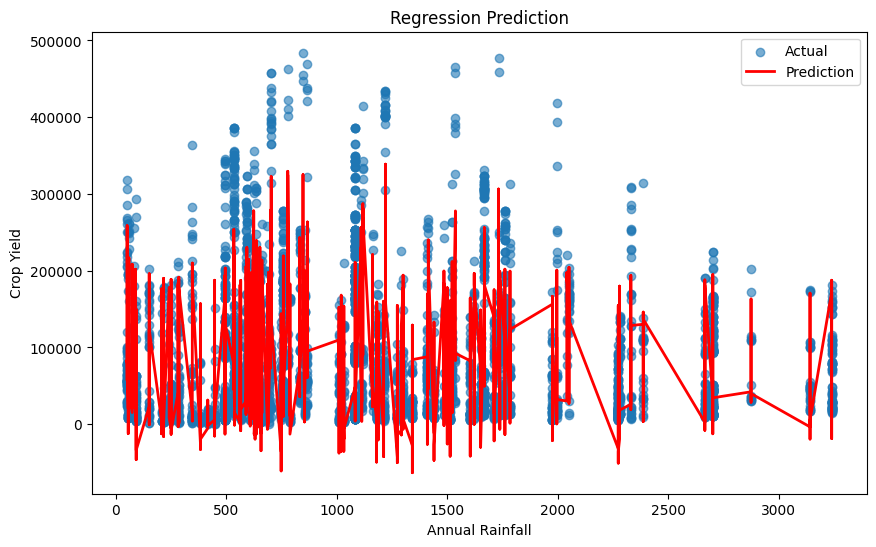

In [ ]:
plot_df = X_test.copy()

plot_df["Actual"] = y_test.values

plot_df["Prediction"] = best_predictions

plot_df = plot_df.sort_values(
    by="average_rain_fall_mm_per_year"
)

plt.figure(figsize=(10,6))

plt.scatter(
    plot_df["average_rain_fall_mm_per_year"],
    plot_df["Actual"],
    label="Actual",
    alpha=0.6
)

plt.plot(
    plot_df["average_rain_fall_mm_per_year"],
    plot_df["Prediction"],
    color="red",
    linewidth=2,
    label="Prediction"
)

plt.xlabel("Annual Rainfall")

plt.ylabel("Crop Yield")

plt.title("Regression Prediction")

plt.legend()

plt.show()

Prediction Function

In [ ]:
def predict_crop_yield(
    area,
    item,
    year,
    rainfall,
    pesticides,
    temperature
):

    sample = pd.DataFrame({

        "Area":[area],

        "Item":[item],

        "Year":[year],

        "average_rain_fall_mm_per_year":[rainfall],

        "pesticides_tonnes":[pesticides],

        "avg_temp":[temperature]

    })

    prediction = best_model.predict(sample)

    return prediction[0]

Example

In [ ]:
predict_crop_yield(
    area="Rwanda",
    item="Maize",
    year=2024,
    rainfall=1200,
    pesticides=45,
    temperature=22
)

np.float64(15568.451415206378)

Save the Final Model

In [ ]:
joblib.dump(best_model,"best_model.pkl")

print("Model saved successfully.")

Final Conclusion

# Conclusion

Four regression algorithms were trained and evaluated for crop yield prediction.

The models were compared using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

The best-performing model achieved the highest prediction accuracy and was selected for deployment. The trained pipeline was saved and will be integrated into a FastAPI service to provide real-time crop yield predictions that can be accessed through a Flutter mobile application.